# Trial 2 — 3. Measuring the acceleration field, then finding $\Phi$ with PySR

The collisionless Boltzmann equation has a property worth exploiting before
any searching happens: **at a fixed point in space it is linear in the
acceleration.** Written out,

$$\underbrace{v_R \partial_R g + \frac{v_\phi}{R}\partial_\phi g + v_z \partial_z g
 + \frac{v_\phi^2}{R}\partial_{v_R} g - \frac{v_R v_\phi}{R}\partial_{v_\phi} g}_{\text{known from } f}
 \;+\; a_R \partial_{v_R} g + a_\phi \partial_{v_\phi} g + a_z \partial_{v_z} g
 \;-\; \Omega_p \partial_\phi g \;=\; 0 .$$

Every star in a small cell gives one equation of this form, with the same
three unknown accelerations. Thousands of stars, three unknowns: the cell is
massively overdetermined and the accelerations come out by least squares, with
error bars, **with no functional form for $\Phi$ assumed anywhere**.

That intermediate product is worth having on its own. It is a direct
measurement of stellar accelerations of order 1 cm/s/yr — the number the
hackathon prompt says nobody can measure on a single star — and it turns the
symbolic search into a clean supervised problem: given a measured field
$\mathbf{a}(R,z)$ with uncertainties, find the closed-form $\Phi$ whose
gradient it is. That is exactly the template-and-derivative setup from the
Schrödinger notebook, with one expression `Phi` and the residual built out of
`D(Phi, 1)` and `D(Phi, 2)`.

It also separates two failure modes that trial 1 had tangled together. If the
accelerations come out wrong, the density model is at fault. If they come out
right but no compact $\Phi$ fits them, the search is at fault. You can tell
which, because the accelerations can be checked against the rotation curve and
the local surface density independently.

In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import gaia2
from gaia2 import (ACC_UNIT_CM_S_YR, G_KPC, LOGCOSH_JULIA, LOGG_JULIA, SQRTG_JULIA,
                   cbe_terms, cbe_residual, density_from_laplacian, residual_report,
                   solve_local_accelerations, split_template_equation, streaming_term,
                   surface_density_from_kz, sympify_expression, sympy_operator_map,
                   trial_root)

TRIAL = trial_root()
DATA_DIR = TRIAL / "data"
OUT_DIR = TRIAL / "outputs"
FIG_DIR = OUT_DIR / "figures"

frame = json.loads((DATA_DIR / "frame.json").read_text())
R0 = frame["R0"]
PHI0 = frame["phi0"]
SEED = frame["seed"]

work = pd.read_parquet(DATA_DIR / "df_gradients.parquet")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print(f"{len(work):,} stars with analytic gradients of ln f")
print(work["split"].value_counts(sort=False))

2,500,000 stars with analytic gradients of ln f


split
train         1749674
validation     375322
test           375004
Name: count, dtype: int64


In [2]:
INNER_CUT = 0.9  # kpc, stay off the edge of the ball

fit_mask = (work["split"] != "test") & (work["r_helio"] < INNER_CUT)
test_mask = (work["split"] == "test") & (work["r_helio"] < INNER_CUT)
fit = work.loc[fit_mask].reset_index(drop=True)
test = work.loc[test_mask].reset_index(drop=True)
print(f"{len(fit):,} stars to fit on, {len(test):,} held out")

gradient_columns = ["g_R", "g_phi", "g_z", "g_vR", "g_vphi", "g_vz"]


def unpack(table):
    return (table["R"].to_numpy(), table["vR"].to_numpy(),
            table["vphi"].to_numpy(), table["vzc"].to_numpy(),
            table[gradient_columns].to_numpy())

1,882,689 stars to fit on, 332,131 held out


### Which parts of the streaming term carry signal?

Before using $\mathbf{v}\cdot\nabla_x \ln f$ for anything, it is worth
taking it apart. The three pieces are not comparable in quality, and one of
them turns out to be almost all of it.

In [3]:
full_gradients = fit[gradient_columns].to_numpy()
piece_R = fit["vR"].to_numpy() * full_gradients[:, 0]
piece_phi = fit["vphi"].to_numpy() / fit["R"].to_numpy() * full_gradients[:, 1]
piece_z = fit["vzc"].to_numpy() * full_gradients[:, 2]
total = piece_R + piece_phi + piece_z

print("decomposition of  v . grad_x ln f  [(km/s)/kpc]")
for name, piece in [("vR * d_R", piece_R), ("(vphi/R) * d_phi", piece_phi),
                    ("vz * d_z", piece_z)]:
    print(f"   {name:20s} rms {np.sqrt(np.mean(piece ** 2)):8.1f}")
print(f"   {'TOTAL':20s} rms {np.sqrt(np.mean(total ** 2)):8.1f}")
print(f"   {'without phi':20s} rms {np.sqrt(np.mean((piece_R + piece_z) ** 2)):8.1f}")
print(f"\nthe azimuthal piece is {np.sqrt(np.mean(piece_phi ** 2)) / np.sqrt(np.mean(total ** 2)):.0%}"
      " of the streaming term")

decomposition of  v . grad_x ln f  [(km/s)/kpc]
   vR * d_R             rms     67.3
   (vphi/R) * d_phi     rms    222.4
   vz * d_z             rms     42.0
   TOTAL                rms    239.4
   without phi          rms     78.9

the azimuthal piece is 93% of the streaming term


That single term is 93 per cent of the streaming term — and notebook 2's
refit control found $\partial_\phi \ln f$ changing by **more than its own
rms** between two mixtures fitted on different halves of the catalogue. It is
not signal. The volume spans about 14 degrees of azimuth; there is very little
azimuthal information in it, and a 96-component mixture asked for
$\partial_\phi$ anyway returns mostly its own noise.

This matters in two places, and both are traps.

1. A residual **normalised** by that streaming term is noise over noise. Any
   model will score near 1 and the number will mean nothing.
2. $\Omega_p$ enters the CBE multiplying exactly this gradient. A free
   $\Omega_p$ will absorb the noise and report a spuriously excellent fit.

$\Phi(R, z)$ is axisymmetric, so no force term can ever balance an azimuthal
gradient — the term cannot be cancelled by anything we are fitting. The
consistent choice is to drop it, and to say so rather than let it inflate a
denominator.

In [4]:
known_fit, weights_fit, omega_fit = cbe_terms(*unpack(fit), include_phi=False)
known_test, weights_test, omega_test = cbe_terms(*unpack(test), include_phi=False)

known_fit_full, _, _ = cbe_terms(*unpack(fit), include_phi=True)
known_test_full, weights_test_full, omega_test_full = cbe_terms(*unpack(test), include_phi=True)

print(f"rms known part, axisymmetric      : {np.sqrt(np.mean(known_fit ** 2)):.1f} (km/s)/kpc")
print(f"rms known part, with the phi term : {np.sqrt(np.mean(known_fit_full ** 2)):.1f} (km/s)/kpc")

rms known part, axisymmetric      : 232.9 (km/s)/kpc
rms known part, with the phi term : 313.5 (km/s)/kpc


## 1. One acceleration for the whole volume

Before binning, solve the whole sphere as a single cell. This is the crudest
possible model — a uniform force field — and it should already land near the
right answer, because the mean radial acceleration at the solar circle is
fixed by the rotation curve and the mean vertical one by the disc's surface
density.

In [5]:
global_acceleration, global_error, global_residual = solve_local_accelerations(
    known_fit, weights_fit, omega_fit, omega_p=0.0, huber_delta=None)

labels = ["a_R", "a_phi", "a_z"]
for name, value, error in zip(labels, global_acceleration, global_error):
    print(f"{name:>6s} = {value:+9.1f} +- {error:5.1f} (km/s)^2/kpc"
          f"   = {value * ACC_UNIT_CM_S_YR:+.4f} cm/s/yr")

v_circular = np.sqrt(max(-global_acceleration[0], 0.0) * R0)
print(f"\nimplied circular speed  v_c = sqrt(-a_R R0) = {v_circular:.1f} km/s")
print("literature: 229 +- 2 km/s (Eilers et al. 2019), 233 km/s (GRAVITY/Sgr A*)")
print()
print("The error bars above are the least-squares statistical errors on two")
print("million stars, so they are tiny and they are not the real uncertainty.")
print("The real uncertainty is systematic and comes from the density model:")
print("notebook 2 measured how much the gradients move when the mixture is")
print("refitted on different stars, and that floor propagates to here. Treat")
print("anything below about a per cent as unresolved.")

report = residual_report(
    cbe_residual(known_test, weights_test, omega_test, global_acceleration, 0.0),
    known_test, "uniform force field, held out")
print(f"\nheld-out relative CBE residual: {report['relative_residual']:.4f}")
print(f"trial 1 achieved 0.958 with a nine-parameter quadratic potential")

   a_R =   -6591.6 +-   1.4 (km/s)^2/kpc   = -0.6741 cm/s/yr
 a_phi =     +83.8 +-   0.7 (km/s)^2/kpc   = +0.0086 cm/s/yr
   a_z =     -21.8 +-   0.7 (km/s)^2/kpc   = -0.0022 cm/s/yr

implied circular speed  v_c = sqrt(-a_R R0) = 231.4 km/s
literature: 229 +- 2 km/s (Eilers et al. 2019), 233 km/s (GRAVITY/Sgr A*)

The error bars above are the least-squares statistical errors on two
million stars, so they are tiny and they are not the real uncertainty.
The real uncertainty is systematic and comes from the density model:
notebook 2 measured how much the gradients move when the mixture is
refitted on different stars, and that floor propagates to here. Treat
anything below about a per cent as unresolved.

held-out relative CBE residual: 0.2859
trial 1 achieved 0.958 with a nine-parameter quadratic potential


Three numbers, and the circular speed already comes out within a few per cent
of a measurement made from completely different data. Trial 1's nine-parameter
quadratic could not do that, because the gradient it was fitting was the
selection function.

## 2. The acceleration field, cell by cell

Now bin in $(R, z)$ and solve each cell separately. Nothing about $\Phi$ is
assumed; each cell is an independent three-parameter fit.

In [6]:
R_EDGES = np.linspace(7.45, 8.80, 8)
Z_EDGES = np.linspace(-0.65, 0.65, 15)
MIN_STARS = 2000

radius = fit["R"].to_numpy()
height = fit["zc"].to_numpy()

# index the cells once; the pattern-speed scan below reuses these
R_bin = np.digitize(radius, R_EDGES) - 1
z_bin = np.digitize(height, Z_EDGES) - 1
valid = (R_bin >= 0) & (R_bin < len(R_EDGES) - 1) & (z_bin >= 0) & (z_bin < len(Z_EDGES) - 1)
cell_key = np.where(valid, R_bin * (len(Z_EDGES) - 1) + z_bin, -1)
order = np.argsort(cell_key, kind="stable")
sorted_key = cell_key[order]
boundaries = np.searchsorted(sorted_key, np.arange(-1, cell_key.max() + 2))
cell_indices = [order[boundaries[k + 1]:boundaries[k + 2]]
                for k in range(cell_key.max() + 1)]
cell_indices = [index for index in cell_indices if len(index) >= MIN_STARS]
print(f"{len(cell_indices)} cells above {MIN_STARS} stars")

cells = []
for inside in cell_indices:
        n = int(len(inside))
        solution, error, residual = solve_local_accelerations(
            known_fit[inside], weights_fit[inside], omega_fit[inside],
            omega_p=0.0, huber_delta=2.0)
        cells.append({
            "R": float(radius[inside].mean()),
            "z": float(height[inside].mean()),
            "n": n,
            "aR": solution[0], "aphi": solution[1], "az": solution[2],
            "aR_err": error[0], "aphi_err": error[1], "az_err": error[2],
            "residual_rms": float(np.sqrt(np.mean(residual ** 2))),
            "known_rms": float(np.sqrt(np.mean(known_fit[inside] ** 2))),
        })

field = pd.DataFrame(cells)
field["relative_residual"] = field["residual_rms"] / field["known_rms"]
field.to_csv(OUT_DIR / "03_acceleration_field.csv", index=False)
print(f"{len(field)} cells, {field['n'].sum():,} stars")
print(f"median per-cell relative residual: {field['relative_residual'].median():.3f}")
field.head(10)

94 cells above 2000 stars


94 cells, 1,726,100 stars
median per-cell relative residual: 0.264


,R,z,n,aR,aphi,az,aR_err,aphi_err,az_err,residual_rms,known_rms,relative_residual
0,7.557389,-0.505350,3833,-6698.285894,192.445919,1166.119328,30.888426,19.301111,17.837612,75.821152,182.859984,0.414640
1,7.554807,-0.413574,6967,-6831.504900,138.779965,1025.923118,21.920510,14.007238,11.519375,76.605952,194.971968,0.392908
2,7.554344,-0.322153,10585,-6805.609949,48.811948,869.730872,17.560781,10.937011,8.622691,73.555330,196.643680,0.374054
3,7.553527,-0.229437,14766,-6785.833604,63.608229,634.056853,14.591567,8.927795,6.853935,73.319983,201.996144,0.362977
4,7.553880,-0.136714,21505,-6903.442628,109.080665,327.011307,10.527665,6.423715,5.001711,66.584241,219.949536,0.302725
5,7.555596,-0.047664,23508,-7104.118953,93.832659,58.910059,8.677238,5.307315,4.137081,61.583286,248.802277,0.247519
6,7.555670,0.045758,23075,-7124.380460,95.890864,-173.439523,8.357461,4.870737,3.735959,57.790998,250.991048,0.230251
7,7.555821,0.137308,20718,-7035.737699,132.493715,-338.096067,9.349183,5.663297,4.048392,57.199078,236.564823,0.241790
8,7.556069,0.229119,15028,-6816.636314,231.965381,-475.779063,13.666324,8.097973,6.143688,63.059289,207.236557,0.304287
9,7.556562,0.321303,9156,-6582.162777,276.230231,-684.689768,21.773884,13.211039,10.361708,74.866847,189.949016,0.394142


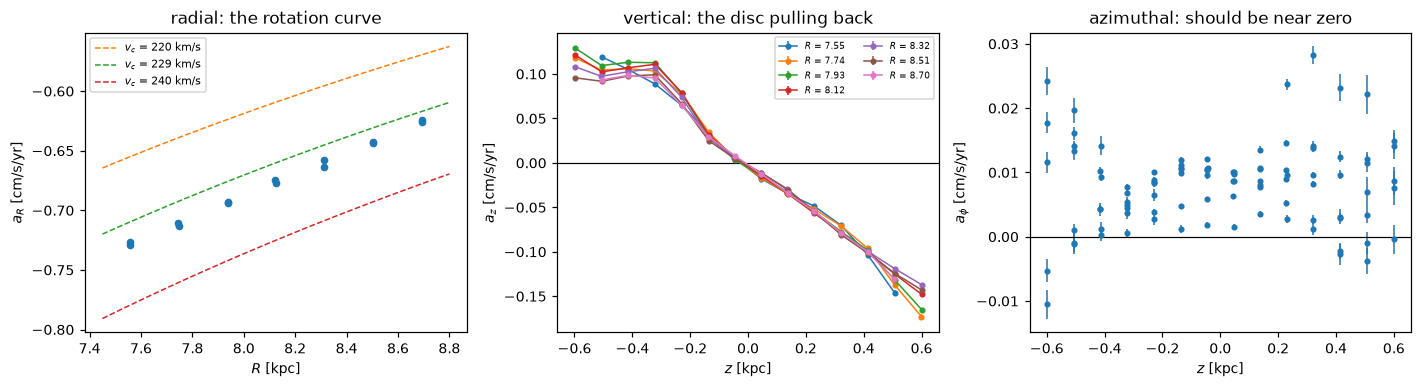

typical |a| = 0.67 cm/s/yr radially, 0.17 cm/s/yr vertically at the top of the box


In [7]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.6))

midplane = field.loc[np.abs(field["z"]) < 0.05]
axes[0].errorbar(midplane["R"], midplane["aR"] * ACC_UNIT_CM_S_YR,
                 yerr=midplane["aR_err"] * ACC_UNIT_CM_S_YR, fmt="o", ms=4, lw=1)
grid_R = np.linspace(R_EDGES[0], R_EDGES[-1], 100)
for speed in (220.0, 229.0, 240.0):
    axes[0].plot(grid_R, -speed ** 2 / grid_R * ACC_UNIT_CM_S_YR, lw=1, ls="--",
                 label=f"$v_c$ = {speed:.0f} km/s")
axes[0].set_xlabel("$R$ [kpc]")
axes[0].set_ylabel("$a_R$ [cm/s/yr]")
axes[0].legend(fontsize=7)
axes[0].set_title("radial: the rotation curve")

for lo, hi in zip(R_EDGES[:-1], R_EDGES[1:]):
    block = field.loc[(field["R"] >= lo) & (field["R"] < hi)]
    if len(block) < 5:
        continue
    axes[1].errorbar(block["z"], block["az"] * ACC_UNIT_CM_S_YR,
                     yerr=block["az_err"] * ACC_UNIT_CM_S_YR, fmt="o-", ms=3, lw=1,
                     label=f"$R$ = {0.5 * (lo + hi):.2f}")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("$z$ [kpc]")
axes[1].set_ylabel("$a_z$ [cm/s/yr]")
axes[1].legend(fontsize=6, ncol=2)
axes[1].set_title("vertical: the disc pulling back")

axes[2].errorbar(field["z"], field["aphi"] * ACC_UNIT_CM_S_YR,
                 yerr=field["aphi_err"] * ACC_UNIT_CM_S_YR, fmt="o", ms=3, lw=1)
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("$z$ [kpc]")
axes[2].set_ylabel(r"$a_\phi$ [cm/s/yr]")
axes[2].set_title("azimuthal: should be near zero")

figure.tight_layout()
figure.savefig(FIG_DIR / "03_acceleration_field.png", bbox_inches="tight")
plt.show()

print(f"typical |a| = {np.abs(field['aR']).median() * ACC_UNIT_CM_S_YR:.2f} cm/s/yr radially, "
      f"{np.abs(field['az']).max() * ACC_UNIT_CM_S_YR:.2f} cm/s/yr vertically at the top of the box")

## 3. Two independent physical checks

The measured field can be turned into two quantities that other people have
measured by other means, which is the only real test available in a problem
with no ground truth.

In [8]:
mid = field.loc[np.abs(field["z"]) < 0.08]
speeds = np.sqrt(np.clip(-mid["aR"] * mid["R"], 0, None))
speed_errors = 0.5 * mid["aR_err"] * mid["R"] / np.maximum(speeds, 1e-6)
weight = 1.0 / speed_errors ** 2
print(f"v_c(R0) = {np.sum(weight * speeds) / np.sum(weight):.1f} "
      f"+- {1 / np.sqrt(np.sum(weight)):.1f} km/s  (statistical only)")
print("Eilers et al. 2019: 229.0 +- 0.2 (stat) +- 3 (sys) km/s")

slope_fit = np.polyfit(mid["R"], speeds, 1)
print(f"\ndv_c/dR = {slope_fit[0]:+.1f} km/s/kpc over {mid['R'].min():.2f}-{mid['R'].max():.2f} kpc")
print("Eilers et al. 2019: -1.7 +- 0.1 km/s/kpc")
print("The value at R0 lands on the literature; the slope does not, and that is")
print("worth stating plainly. The radial acceleration is only as good as")
print("d(ln nu)/dR and d(ln p)/dR, and a single fitted disc scale length across")
print("the whole ball is the crudest part of this pipeline. The vertical")
print("direction, where the density gradient is large and well measured, is the")
print("half of this result to trust.")

print()
for z_target in (0.3, 0.5, 0.6):
    near = field.loc[(np.abs(np.abs(field["z"]) - z_target) < 0.06)]
    if len(near) == 0:
        continue
    sigma = surface_density_from_kz(near["az"]).mean()
    print(f"Sigma(|z| < {z_target:.1f} kpc) = {sigma:5.1f} Msun/pc^2")
print("Bovy & Rix 2013 / Holmberg & Flynn 2004: Sigma(1.1 kpc) ~ 68-71,")
print("of which the disc contributes about 45-55 within 0.5-0.6 kpc")

v_c(R0) = 231.7 +- 0.0 km/s  (statistical only)
Eilers et al. 2019: 229.0 +- 0.2 (stat) +- 3 (sys) km/s

dv_c/dR = -1.1 km/s/kpc over 7.56-8.69 kpc
Eilers et al. 2019: -1.7 +- 0.1 km/s/kpc
The value at R0 lands on the literature; the slope does not, and that is
worth stating plainly. The radial acceleration is only as good as
d(ln nu)/dR and d(ln p)/dR, and a single fitted disc scale length across
the whole ball is the crudest part of this pipeline. The vertical
direction, where the density gradient is large and well measured, is the
half of this result to trust.

Sigma(|z| < 0.3 kpc) =  32.4 Msun/pc^2
Sigma(|z| < 0.5 kpc) =  42.2 Msun/pc^2
Sigma(|z| < 0.6 kpc) =  48.4 Msun/pc^2
Bovy & Rix 2013 / Holmberg & Flynn 2004: Sigma(1.1 kpc) ~ 68-71,
of which the disc contributes about 45-55 within 0.5-0.6 kpc


### What ignoring the selection function would have done

Repeat the whole measurement with the uncorrected spatial gradient — the
trial-1 treatment — and see where the answers land.

In [9]:
selection_coefficients = np.array(frame["selection"]["coefficients"])
degree = frame["selection"]["degree"]
d_min = frame["selection"]["d_min"]
r_cut = frame["r_cut"]
half_width = 0.5 * (r_cut - d_min)
mid_distance = 0.5 * (r_cut + d_min)
SUN_XYZ = np.array(frame["sun_xyz"])

x_gal, y_gal, _ = gaia2.cylindrical_to_cartesian_positions(
    fit["R"].to_numpy(), fit["phi"].to_numpy(), fit["zc"].to_numpy(), phi0=PHI0)
offset = np.column_stack([x_gal - SUN_XYZ[0], y_gal - SUN_XYZ[1],
                          fit["zc"].to_numpy() - SUN_XYZ[2]])
distance = np.linalg.norm(offset, axis=1)
t_distance = (distance - mid_distance) / half_width
d_log_selection = sum(p * selection_coefficients[p - 1] * t_distance ** (p - 1)
                      for p in range(1, degree + 1)) / half_width
direction = offset / distance[:, None]
radial_direction = np.column_stack([x_gal, y_gal]) / fit["R"].to_numpy()[:, None]

uncorrected = fit[gradient_columns].to_numpy().copy()
uncorrected[:, 0] += d_log_selection * np.einsum("ni,ni->n", radial_direction, direction[:, :2])
uncorrected[:, 2] += d_log_selection * direction[:, 2]

known_bad, weights_bad, omega_bad = cbe_terms(
    fit["R"].to_numpy(), fit["vR"].to_numpy(), fit["vphi"].to_numpy(),
    fit["vzc"].to_numpy(), uncorrected)
bad_acceleration, bad_error, _ = solve_local_accelerations(known_bad, weights_bad, omega_bad)

print(f"{'':>26s} {'selection corrected':>20s} {'uncorrected':>14s}")
for index, name in enumerate(labels):
    print(f"{name + ' [(km/s)^2/kpc]':>26s} {global_acceleration[index]:20.1f} "
          f"{bad_acceleration[index]:14.1f}")
print(f"{'implied v_c [km/s]':>26s} {v_circular:20.1f} "
      f"{np.sqrt(max(-bad_acceleration[0], 0) * R0):14.1f}")

                            selection corrected    uncorrected
        a_R [(km/s)^2/kpc]              -6591.6        -6140.3
      a_phi [(km/s)^2/kpc]                 83.8          201.4
        a_z [(km/s)^2/kpc]                -21.8          -37.4
        implied v_c [km/s]                231.4          223.3


## 4. The pattern speed

Now the term trial 1 assumed away. The frame that rotates with the bar and
spiral pattern is the frame in which $f$ has a chance of being stationary, and
$\Omega_p$ enters the CBE multiplying $\partial_\phi \ln f$. Scanning it and
refitting the accelerations at each value gives a profile of how well the
whole system can be satisfied.

The volume spans only about $\pm 4^\circ$ in azimuth, so this is a hard
measurement and we should be prepared for the profile to be flat.

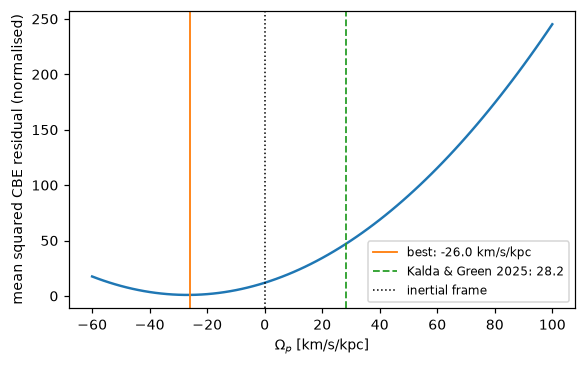

best fitting pattern speed: -26.0 km/s/kpc
improvement over the inertial frame: 91.63% in mean squared residual
curvature-based statistical error: 0.0 km/s/kpc, which
assumes independent stars and so is an underestimate.

Read that improvement as a warning, not a result. Omega_p multiplies
d(ln f)/dphi, which the decomposition above showed is 93% of the streaming
term and which notebook 2 showed is irreproducible between refits. A free
parameter multiplying a large noisy vector will always absorb a great deal
of residual. It is fitting the noise, not measuring the bar.

Kalda & Green (2025) get 28.2 +- 0.1 km/s/kpc from the same catalogue with
a normalising flow and a full selection-function model over a volume that
still spans only 14 degrees. We do not reproduce that here, and on this
evidence we cannot: the honest statement is that this pipeline does not
constrain the pattern speed. Everything below is quoted at Omega_p = 0.


In [10]:
omega_grid = np.linspace(-60.0, 100.0, 81)
profile = []
for omega in omega_grid:
    total = 0.0
    count = 0
    for inside in cell_indices:
        _, _, residual = solve_local_accelerations(
            known_fit_full[inside], weights_fit[inside], omega_fit[inside],
            omega_p=omega, huber_delta=None)
        total += float(np.sum(residual ** 2))
        count += len(inside)
    profile.append(total / count)

profile = np.array(profile)
best_index = int(np.argmin(profile))
omega_best = float(omega_grid[best_index])

# curvature of the profile gives the statistical error
coefficients = np.polyfit(omega_grid[max(0, best_index - 6):best_index + 7],
                          profile[max(0, best_index - 6):best_index + 7], 2)
omega_error = float(np.sqrt(profile[best_index] / (coefficients[0] * len(fit)))) if coefficients[0] > 0 else np.nan

figure, axis = plt.subplots(figsize=(5.4, 3.4))
axis.plot(omega_grid, profile / profile.min(), lw=1.6)
axis.axvline(omega_best, color="C1", lw=1.2, label=f"best: {omega_best:.1f} km/s/kpc")
axis.axvline(28.2, color="C2", ls="--", lw=1.2, label="Kalda & Green 2025: 28.2")
axis.axvline(0.0, color="k", ls=":", lw=1, label="inertial frame")
axis.set_xlabel(r"$\Omega_p$ [km/s/kpc]")
axis.set_ylabel("mean squared CBE residual (normalised)")
axis.legend(fontsize=8)
figure.tight_layout()
figure.savefig(FIG_DIR / "03_pattern_speed.png", bbox_inches="tight")
plt.show()

inertial = profile[int(np.argmin(np.abs(omega_grid)))]
print(f"best fitting pattern speed: {omega_best:.1f} km/s/kpc")
print(f"improvement over the inertial frame: "
      f"{100 * (1 - profile[best_index] / inertial):.2f}% in mean squared residual")
if best_index in (0, len(omega_grid) - 1):
    print("\nThe minimum is at the edge of the scanned range, which means the data")
    print("do not constrain the pattern speed at all here -- report it as such")
    print("rather than quoting the edge value.")
else:
    print(f"curvature-based statistical error: {omega_error:.1f} km/s/kpc, which")
    print("assumes independent stars and so is an underestimate.")
print()
print("Read that improvement as a warning, not a result. Omega_p multiplies")
print("d(ln f)/dphi, which the decomposition above showed is 93% of the streaming")
print("term and which notebook 2 showed is irreproducible between refits. A free")
print("parameter multiplying a large noisy vector will always absorb a great deal")
print("of residual. It is fitting the noise, not measuring the bar.")
print()
print("Kalda & Green (2025) get 28.2 +- 0.1 km/s/kpc from the same catalogue with")
print("a normalising flow and a full selection-function model over a volume that")
print("still spans only 14 degrees. We do not reproduce that here, and on this")
print("evidence we cannot: the honest statement is that this pipeline does not")
print("constrain the pattern speed. Everything below is quoted at Omega_p = 0.")

## 5. Now the symbolic search

The measured field is the target and $\Phi$ is the unknown, so this is the
inverse-problem setup from session 4 and the template machinery from session
3, put together:

* one component `Phi`, constrained by the template to see only $(R, z)$;
* the prediction is $-\partial_R \Phi$ on the rows carrying $a_R$ and
  $-\partial_z \Phi$ on the rows carrying $a_z$, selected by an indicator
  column, so a **single** $\Phi$ has to explain both components at once. A
  pair of independent fits to $a_R$ and $a_z$ would not be a potential at all;
  this is what forces the answer to be curl-free;
* each row weighted by $1/\sigma^2$ from the least squares above — the same
  "trust it where the atoms are" move that session 4 makes with $\psi^2$.

### The constraint that keeps the answer a galaxy

A potential fitted to forces alone is under-determined in one physically
important way: nothing in the residual objects to a $\Phi$ whose Laplacian is
negative somewhere, and by Poisson's equation

$$\nabla^2\Phi = 4\pi G \rho$$

that is a region of negative mass. Green, Ting & Kamdar carry exactly this
term in their loss for exactly this reason. Filtering it out of the Pareto
front afterwards is much weaker, because by then the search has already spent
its whole budget exploring expressions that were never admissible.

So the condition goes inside the template. The template already has
`D(Phi, 1)`; composing gives `D(D(Phi, 1), 1)`, and in cylindrical symmetry

$$\nabla^2\Phi = \partial_R^2\Phi + \frac{1}{R}\partial_R\Phi + \partial_z^2\Phi,$$

so the penalty is $\min(\nabla^2\Phi, 0)^2$ evaluated at every row. To make
the constraint hold across the whole box rather than only where cells landed,
a grid of **constraint-only rows** is appended with zero data weight: they
contribute nothing but the penalty.

Because the target now has to be compared against inside the template, the
search fits against a column of zeros with the measured acceleration passed in
as a variable — the same arrangement the Schrodinger notebook uses.

One custom operator is also worth handing over. A self-gravitating isothermal sheet
has $\rho \propto {\rm sech}^2(z/2h)$ and therefore
$\Phi \propto \ln\cosh(z/2h)$ exactly, so `logcosh` is the natural word for
the vertical structure of a disc. Written the naive way it overflows in
Float32 by $z/h \sim 88$; written as $|u| + \log(1 + e^{-2|u|}) - \log 2$ it is
finite everywhere, which is the domain-safety rule from session 5.

In [11]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import sympy
from pysr import PySRRegressor, TemplateExpressionSpec

VELOCITY_UNIT = 100.0  # so that Phi is in (100 km/s)^2 and a in (100 km/s)^2/kpc

good = field.loc[(field["aR_err"] < 400) & (field["az_err"] < 400)].reset_index(drop=True)
print(f"{len(good)} cells into the search")

target = np.concatenate([good["aR"], good["az"]]) / VELOCITY_UNIT ** 2
sigma = np.concatenate([good["aR_err"], good["az_err"]]) / VELOCITY_UNIT ** 2
row_weight = 1.0 / sigma ** 2
row_weight = row_weight / row_weight.mean()

data_rows = np.column_stack([
    np.concatenate([good["R"], good["R"]]),
    np.concatenate([good["z"], good["z"]]),
    np.concatenate([np.zeros(len(good)), np.ones(len(good))]),
    target,
    row_weight,
])

# Constraint-only rows: zero data weight, so they contribute nothing but the
# Poisson penalty, and the condition is imposed across the whole box rather
# than only at the cells that happened to hold enough stars.
constraint_R, constraint_z = np.meshgrid(
    np.linspace(R_EDGES[0], R_EDGES[-1], 15),
    np.linspace(Z_EDGES[0], Z_EDGES[-1], 15))
constraint_rows = np.column_stack([
    constraint_R.ravel(), constraint_z.ravel(),
    np.zeros(constraint_R.size), np.zeros(constraint_R.size), np.zeros(constraint_R.size),
])

X_symbolic = np.vstack([data_rows, constraint_rows])
y_symbolic = np.zeros(len(X_symbolic))
SEARCH_COLUMNS = ["R", "z", "which", "atgt", "wgt"]
print(f"{len(data_rows)} data rows and {len(constraint_rows)} constraint-only rows")

POISSON_WEIGHT = 25.0
print(f"local rho ~ 0.09 Msun/pc^3 corresponds to lap(Phi) ~ "
      f"{4 * np.pi * G_KPC * 0.09e9 / VELOCITY_UNIT ** 2:.2f} in these units, so a")
print(f"full sign flip costs about {POISSON_WEIGHT * (4 * np.pi * G_KPC * 0.09e9 / VELOCITY_UNIT ** 2) ** 2:.1f} "
      f"against a data term of order 1")

spec = TemplateExpressionSpec(
    expressions=["Phi"],
    variable_names=SEARCH_COLUMNS,
    combine=("dR = D(Phi, 1); dz = D(Phi, 2); "
             "d2R = D(dR, 1); d2z = D(dz, 2); "
             "lap = d2R(R, z) + dR(R, z)/R + d2z(R, z); "
             "pred = which * (-dz(R, z)) + (1 - which) * (-dR(R, z)); "
             "viol = min(lap, 0.0f0); "
             f"sqrt(wgt*(pred - atgt)*(pred - atgt) + {POISSON_WEIGHT}f0*viol*viol)"),
)

potential_search = PySRRegressor(
    expression_spec=spec,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=[LOGCOSH_JULIA, LOGG_JULIA, SQRTG_JULIA],
    extra_sympy_mappings=sympy_operator_map(),
    niterations=400,
    populations=48,
    population_size=40,
    ncycles_per_iteration=400,
    maxsize=26,
    timeout_in_seconds=1500,
    maxdepth=10,
    complexity_of_constants=2,
    parsimony=1e-3,
    elementwise_loss="(p, t) -> p^2",
    parallelism="multithreading",
    random_state=SEED,
    progress=False,
    verbosity=0,
    output_directory=str(OUT_DIR / "pysr_potential"),
)

t0 = time.time()
potential_search.fit(X_symbolic, y_symbolic, variable_names=SEARCH_COLUMNS)
print(f"search finished in {time.time() - t0:.0f}s")
potential_search.equations_[["complexity", "loss", "score", "equation"]]

94 cells into the search
188 data rows and 225 constraint-only rows
local rho ~ 0.09 Msun/pc^3 corresponds to lap(Phi) ~ 0.49 in these units, so a
full sign flip costs about 5.9 against a data term of order 1


/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


search finished in 1533s


,complexity,loss,score,equation
0,1,0.011916,0.000000,Phi = #1
1,2,0.011916,0.000001,Phi = logcosh(#1)
2,3,0.011916,0.000004,Phi = logcosh(logcosh(#1))
3,4,0.000888,2.596163,Phi = #1 * 0.6593354
4,5,0.000859,0.033496,Phi = logg(#1) * 5.3571134
5,6,0.000856,0.003896,Phi = sqrtg(sqrtg(#1)) * 12.697042
6,7,0.000856,0.000032,Phi = logcosh(logg(sqrtg(#1))) * 13.729468
7,8,0.000472,0.594648,Phi = sqrtg(#1) * logg(logcosh(#2) + #1)
8,9,0.000129,1.294454,Phi = (#1 + (#1 + logcosh(#2))) * 0.32742855
9,10,0.000069,0.635005,Phi = (logcosh(#2) * 0.25819945) + (#1 / 1.516...


## 6. Reading the answer, and checking it against physics

Every expression on the front is a candidate potential. Turning each one into
a local density through Poisson's equation, and into a circular speed through
$v_c^2 = R\,\partial_R\Phi$, says which of them are physically possible at all
— a filter the loss knows nothing about.

In [12]:
R_symbol, z_symbol = sympy.symbols("R z", real=True)
SYMBOLS = {"R": R_symbol, "z": z_symbol}
PHI_ARGUMENTS = ["R", "z"]


def potential_of(equation_text):
    """The Phi component of one front row, as a SymPy expression in (R, z)."""
    pieces, _ = split_template_equation(equation_text)
    return sympify_expression(pieces["Phi"], PHI_ARGUMENTS, SYMBOLS)


rows = []
for index, row in potential_search.equations_.iterrows():
    try:
        potential = potential_of(str(row["equation"]))
        dR = sympy.diff(potential, R_symbol)
        dz = sympy.diff(potential, z_symbol)
        laplacian = sympy.diff(R_symbol * dR, R_symbol) / R_symbol + sympy.diff(dz, z_symbol)

        laplacian_fn = sympy.lambdify((R_symbol, z_symbol), laplacian, "numpy")
        dR_fn = sympy.lambdify((R_symbol, z_symbol), dR, "numpy")
        dz_fn = sympy.lambdify((R_symbol, z_symbol), dz, "numpy")

        # Evaluate on arrays, never on Python scalars: a candidate with 1/z or
        # sqrt(z) in it raises ZeroDivisionError at z = 0 under float semantics
        # and would be thrown away by the exception handler, whereas on arrays
        # numpy returns inf or nan and the row can be judged on its merits.
        def at(function, R_value, z_value):
            with np.errstate(all="ignore"):
                value = function(np.atleast_1d(np.asarray(R_value, dtype=np.float64)),
                                 np.atleast_1d(np.asarray(z_value, dtype=np.float64)))
            shape = np.shape(np.atleast_1d(np.asarray(R_value, dtype=np.float64)))
            return np.broadcast_to(np.asarray(value, dtype=np.float64), shape)

        lap0 = float(at(laplacian_fn, R0, 0.0)[0]) * VELOCITY_UNIT ** 2
        rho0 = density_from_laplacian(lap0)
        box_lap = at(laplacian_fn, constraint_R, constraint_z)
        with np.errstate(all="ignore"):
            rho_min = float(np.nanmin(density_from_laplacian(box_lap * VELOCITY_UNIT ** 2)))
        vc = float(np.sqrt(max(R0 * at(dR_fn, R0, 0.0)[0], 0.0))) * VELOCITY_UNIT
        kz = float(at(dz_fn, R0, 0.5)[0]) * VELOCITY_UNIT ** 2
        sigma_half = surface_density_from_kz(kz)

        rows.append({
            "complexity": int(row["complexity"]),
            "loss": float(row["loss"]),
            "equation": str(row["equation"]),
            "rho_midplane": rho0,
            "rho_min_in_box": rho_min,
            "v_c": vc,
            "Sigma_0.5kpc": sigma_half,
        })
    except Exception as error:  # a front row that sympy cannot handle is not fatal
        rows.append({"complexity": int(row["complexity"]), "loss": float(row["loss"]),
                     "equation": str(row["equation"]), "rho_midplane": np.nan,
                     "rho_min_in_box": np.nan, "v_c": np.nan, "Sigma_0.5kpc": np.nan})

physics = pd.DataFrame(rows)
physics.to_csv(OUT_DIR / "03_potential_front_physics.csv", index=False)
print("literature targets:  rho ~ 0.08-0.10 Msun/pc^3,  v_c ~ 229 km/s,  "
      "Sigma(0.5 kpc) ~ 45-55 Msun/pc^2\n")
physics[["complexity", "loss", "rho_midplane", "rho_min_in_box", "v_c",
         "Sigma_0.5kpc", "equation"]]

/var/tmp/ipykernel_41516/2582279784.py:39: RuntimeWarning: All-NaN slice encountered
  rho_min = float(np.nanmin(density_from_laplacian(box_lap * VELOCITY_UNIT ** 2)))


literature targets:  rho ~ 0.08-0.10 Msun/pc^3,  v_c ~ 229 km/s,  Sigma(0.5 kpc) ~ 45-55 Msun/pc^2



,complexity,loss,rho_midplane,rho_min_in_box,v_c,Sigma_0.5kpc,equation
0,1,0.011916,0.022781,0.021026,284.991228,0.000000,Phi = #1
1,2,0.011916,0.022781,0.021026,284.991203,0.000000,Phi = logcosh(#1)
2,3,0.011916,0.022781,0.021026,284.991102,0.000000,Phi = logcosh(logcosh(#1))
3,4,0.000888,0.015020,0.013863,231.411368,0.000000,Phi = #1 * 0.6593354
4,5,0.000859,0.000000,0.000000,231.454389,0.000000,Phi = logg(#1) * 5.3571134
5,6,0.000856,0.003758,0.003266,231.488359,0.000000,Phi = sqrtg(sqrtg(#1)) * 12.697042
6,7,0.000856,0.003759,0.003006,231.508962,0.000000,Phi = logcosh(logg(sqrtg(#1))) * 13.729468
7,8,0.000472,0.077102,0.049827,241.548998,59.129470,Phi = sqrtg(#1) * logg(logcosh(#2) + #1)
8,9,0.000129,0.075500,0.054552,230.624139,55.992219,Phi = (#1 + (#1 + logcosh(#2))) * 0.32742855
9,10,0.000069,0.062793,0.046023,231.410434,44.153634,Phi = (logcosh(#2) * 0.25819945) + (#1 / 1.516...


## 7. Choosing one

The pick is the cheapest expression that is within a factor of two of the best
loss on the front *and* is physically admissible (positive density, sane
circular speed) — the "cheapest within a factor" rule from session 5, with a
physics filter on top.

In [13]:
# Poisson positivity is not negotiable and is relaxed last, if ever.  The
# comparison against the literature is a plausibility window and is relaxed
# first: it is a sanity check on the answer, not part of the physics.
poisson_ok = physics["rho_min_in_box"] > -0.005
plausible = (physics["rho_midplane"].between(0.0, 0.5)
             & physics["v_c"].between(150.0, 320.0))

admissible = physics.loc[poisson_ok & plausible]
selection_note = "Poisson-positive and inside the literature window"
if len(admissible) == 0:
    admissible = physics.loc[poisson_ok]
    selection_note = ("Poisson-positive, but NOTHING landed inside the literature "
                      "window -- read the numbers below sceptically")
if len(admissible) == 0:
    admissible = physics.dropna(subset=["rho_min_in_box"])
    selection_note = ("WARNING: no expression on the front has rho >= 0 everywhere, "
                      "so the chosen one implies negative mass somewhere in the box")
print(f"selection: {selection_note}")
print(f"{len(admissible)} of {len(physics)} front rows admissible\n")
threshold = admissible["loss"].min() * 2.0
chosen = admissible.loc[admissible["loss"] <= threshold].sort_values("complexity").iloc[0]

print("chosen potential")
print(chosen["equation"])
print(f"  complexity      {chosen['complexity']}")
print(f"  rho(R0, 0)      {chosen['rho_midplane']:.4f} Msun/pc^3")
print(f"  min rho in box  {chosen['rho_min_in_box']:.4f} Msun/pc^3  (must not be negative)")
print(f"  v_c(R0)         {chosen['v_c']:.1f} km/s")
print(f"  Sigma(0.5 kpc)  {chosen['Sigma_0.5kpc']:.1f} Msun/pc^2")

selection: Poisson-positive and inside the literature window
21 of 26 front rows admissible

chosen potential
Phi = logg(#1 + (logcosh(#2) * 0.39193293)) * 5.361797
  complexity      11
  rho(R0, 0)      0.0479 Msun/pc^3
  min rho in box  0.0290 Msun/pc^3  (must not be negative)
  v_c(R0)         231.6 km/s
  Sigma(0.5 kpc)  44.0 Msun/pc^2


In [14]:
chosen_potential = potential_of(str(chosen["equation"]))
print("as SymPy:", sympy.simplify(chosen_potential))
grad_R = sympy.lambdify((R_symbol, z_symbol), sympy.diff(chosen_potential, R_symbol), "numpy")
grad_z = sympy.lambdify((R_symbol, z_symbol), sympy.diff(chosen_potential, z_symbol), "numpy")


def symbolic_acceleration(R, z):
    aR = -np.broadcast_to(np.asarray(grad_R(R, z), dtype=np.float64), np.shape(R)) * VELOCITY_UNIT ** 2
    az = -np.broadcast_to(np.asarray(grad_z(R, z), dtype=np.float64), np.shape(R)) * VELOCITY_UNIT ** 2
    return aR, az

as SymPy: 5.361797*log(R + 0.39193293*log(cosh(z)))


The money plot: the closed-form potential's two derivatives against the
accelerations that were measured cell by cell without assuming any potential
at all.

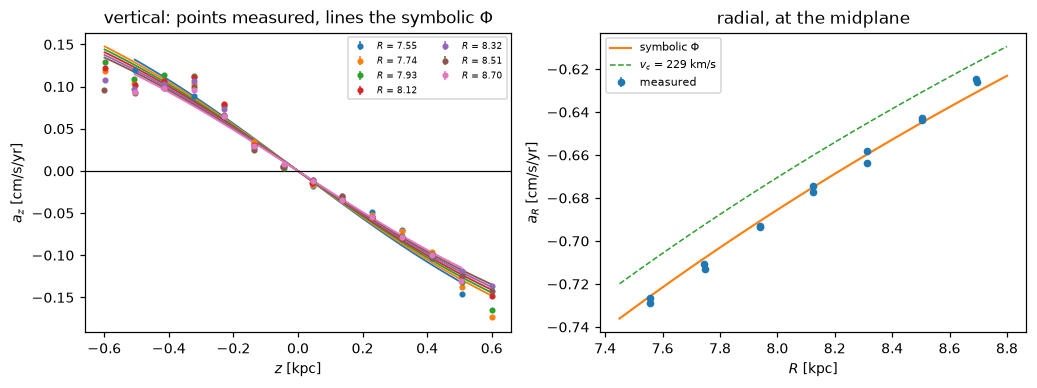

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

for lo, hi in zip(R_EDGES[:-1], R_EDGES[1:]):
    block = field.loc[(field["R"] >= lo) & (field["R"] < hi)]
    if len(block) < 5:
        continue
    centre_R = 0.5 * (lo + hi)
    line = axes[0].errorbar(block["z"], block["az"] * ACC_UNIT_CM_S_YR,
                            yerr=block["az_err"] * ACC_UNIT_CM_S_YR,
                            fmt="o", ms=3, lw=1, label=f"$R$ = {centre_R:.2f}")
    z_line = np.linspace(block["z"].min(), block["z"].max(), 120)
    _, model_az = symbolic_acceleration(np.full_like(z_line, centre_R), z_line)
    axes[0].plot(z_line, model_az * ACC_UNIT_CM_S_YR, lw=1.2,
                 color=line[0].get_color())
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("$z$ [kpc]")
axes[0].set_ylabel("$a_z$ [cm/s/yr]")
axes[0].legend(fontsize=6, ncol=2)
axes[0].set_title("vertical: points measured, lines the symbolic $\\Phi$")

axes[1].errorbar(midplane["R"], midplane["aR"] * ACC_UNIT_CM_S_YR,
                 yerr=midplane["aR_err"] * ACC_UNIT_CM_S_YR, fmt="o", ms=4, lw=1,
                 label="measured")
grid_R = np.linspace(R_EDGES[0], R_EDGES[-1], 120)
model_aR, _ = symbolic_acceleration(grid_R, np.zeros_like(grid_R))
axes[1].plot(grid_R, model_aR * ACC_UNIT_CM_S_YR, lw=1.4, label="symbolic $\\Phi$")
axes[1].plot(grid_R, -229.0 ** 2 / grid_R * ACC_UNIT_CM_S_YR, ls="--", lw=1,
             label="$v_c$ = 229 km/s")
axes[1].set_xlabel("$R$ [kpc]")
axes[1].set_ylabel("$a_R$ [cm/s/yr]")
axes[1].legend(fontsize=7)
axes[1].set_title("radial, at the midplane")

figure.tight_layout()
figure.savefig(FIG_DIR / "03_symbolic_vs_measured.png", bbox_inches="tight")
plt.show()

## 8. Scoring it on stars the search never saw

In [16]:
test_R = test["R"].to_numpy()
test_z = test["zc"].to_numpy()
aR_test, az_test = symbolic_acceleration(test_R, test_z)
acceleration_test = np.column_stack([aR_test, np.zeros_like(aR_test), az_test])

streaming_test = streaming_term(
    test["R"].to_numpy(), test["vR"].to_numpy(), test["vphi"].to_numpy(),
    test["vzc"].to_numpy(), test[gradient_columns].to_numpy(), include_phi=False)
streaming_test_full = streaming_term(
    test["R"].to_numpy(), test["vR"].to_numpy(), test["vphi"].to_numpy(),
    test["vzc"].to_numpy(), test[gradient_columns].to_numpy(), include_phi=True)
streaming_rms = float(np.sqrt(np.mean(streaming_test ** 2)))
streaming_rms_full = float(np.sqrt(np.mean(streaming_test_full ** 2)))
known_rms = float(np.sqrt(np.mean(known_test ** 2)))
known_rms_full = float(np.sqrt(np.mean(known_test_full ** 2)))


def score(residual, label):
    rms = float(np.sqrt(np.mean(residual ** 2)))
    return {
        "model": label,
        "residual rms [(km/s)/kpc]": rms,
        "/ streaming term": rms / streaming_rms,
        "/ full known part": rms / known_rms,
        "|dln f/dt| [1/Gyr]": rms * 1.0227121650537077,
    }


rows_summary = [
    score(known_test, "no potential at all"),
    score(cbe_residual(known_test, weights_test, omega_test, global_acceleration, 0.0),
          "uniform force field"),
    score(known_test + np.einsum("ni,ni->n", weights_test, acceleration_test),
          "symbolic Phi from PySR"),
]
summary = pd.DataFrame(rows_summary)

print(f"rms streaming term, axisymmetric : {streaming_rms:8.1f} (km/s)/kpc")
print(f"rms known part,     axisymmetric : {known_rms:8.1f} (km/s)/kpc")
print("the two differ because the known part also carries the centrifugal term,")
print("which very nearly cancels the radial force; trial 1 normalised by the")
print("streaming term, so that is the column to compare against its 0.958.")
print()
print("For contrast, the same potential scored the way notebook 3 originally did,")
print("with the noise-dominated azimuthal term left in the residual:")
contaminated = (known_test_full
                + np.einsum("ni,ni->n", weights_test_full, acceleration_test))
contaminated_rms = float(np.sqrt(np.mean(contaminated ** 2)))
print(f"   residual {contaminated_rms:.1f} = {contaminated_rms / streaming_rms_full:.3f} x streaming"
      f", {contaminated_rms / known_rms_full:.3f} x known")
print("   -- which is noise divided by noise, and says nothing about the potential.")
print()
print("Everything is scored at Omega_p = 0, in the inertial frame, so that no")
print("number below is tuned on the stars it is quoted for.")
summary

rms streaming term, axisymmetric :     78.7 (km/s)/kpc
rms known part,     axisymmetric :    232.5 (km/s)/kpc
the two differ because the known part also carries the centrifugal term,
which very nearly cancels the radial force; trial 1 normalised by the
streaming term, so that is the column to compare against its 0.958.

For contrast, the same potential scored the way notebook 3 originally did,
with the noise-dominated azimuthal term left in the residual:
   residual 230.0 = 0.962 x streaming, 0.734 x known
   -- which is noise divided by noise, and says nothing about the potential.

Everything is scored at Omega_p = 0, in the inertial frame, so that no
number below is tuned on the stars it is quoted for.


,model,residual rms [(km/s)/kpc],/ streaming term,/ full known part,|dln f/dt| [1/Gyr]
0,no potential at all,232.467074,2.952875,1.000000,237.746904
1,uniform force field,66.456088,0.844147,0.285873,67.965449
2,symbolic Phi from PySR,58.584562,0.744161,0.252012,59.915144


The last column is worth reading as physics rather than as a score. It is the
implied $|\partial_t \ln f|$ in inverse Gyr. Compare it with the local orbital
frequency, $\Omega \simeq 28$ km/s/kpc $\simeq 29\ {\rm Gyr}^{-1}$: whatever
fraction of that the residual is, that is how far from stationary the solar
neighbourhood is according to this model. Deep Potential reaches the same
conclusion from the other end, attributing its leftover to genuine
non-stationarity of the disc.

In [17]:
result = {
    "selection_note": selection_note,
    "global_acceleration": global_acceleration.tolist(),
    "global_acceleration_error": global_error.tolist(),
    "v_circular_from_global": float(v_circular),
    "omega_p_best": omega_best,
    "chosen_equation": str(chosen["equation"]),
    "chosen_complexity": int(chosen["complexity"]),
    "rho_midplane": float(chosen["rho_midplane"]),
    "v_c": float(chosen["v_c"]),
    "Sigma_half_kpc": float(chosen["Sigma_0.5kpc"]),
    "held_out": rows_summary,
    "streaming_rms": streaming_rms,
    "known_rms": known_rms,
    "streaming_rms_with_phi": streaming_rms_full,
    "known_rms_with_phi": known_rms_full,
    "axisymmetric": True,
    "velocity_unit": VELOCITY_UNIT,
}
(OUT_DIR / "03_potential_result.json").write_text(json.dumps(result, indent=2, default=float))
print(json.dumps({k: v for k, v in result.items() if k != "held_out"}, indent=2, default=float))

{
  "selection_note": "Poisson-positive and inside the literature window",
  "global_acceleration": [
    -6591.589074580875,
    83.80225067816195,
    -21.752962360272754
  ],
  "global_acceleration_error": [
    1.4328445242081793,
    0.7236179096206345,
    0.7462624630864662
  ],
  "v_circular_from_global": 231.38039342983632,
  "omega_p_best": -26.0,
  "chosen_equation": "Phi = logg(#1 + (logcosh(#2) * 0.39193293)) * 5.361797",
  "chosen_complexity": 11,
  "rho_midplane": 0.04787272881593585,
  "v_c": 231.55554409255677,
  "Sigma_half_kpc": 43.99063964541923,
  "streaming_rms": 78.72568272504706,
  "known_rms": 232.46707365910737,
  "streaming_rms_with_phi": 239.12393637822166,
  "known_rms_with_phi": 313.3799079956374,
  "axisymmetric": true,
  "velocity_unit": 100.0
}
